In [2]:
import pandas as pd

df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt

In [5]:
print(df.columns)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')


<Axes: >

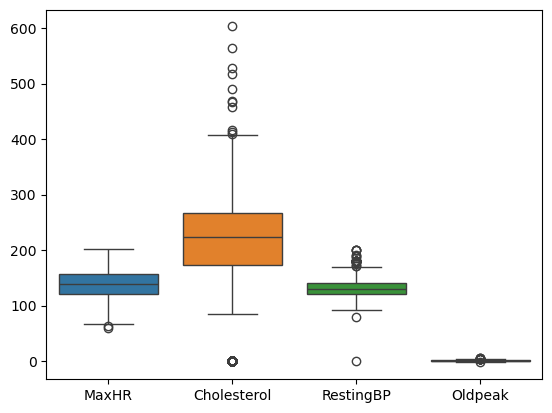

In [7]:
import seaborn as sns

sns.boxplot(data = df[['MaxHR', 'Cholesterol', 'RestingBP', 'Oldpeak']])

In [8]:
df = df[df['Cholesterol'] != 0]
df = df[df['RestingBP'] != 0]

In [ ]:
# Removing outliers:

cols = ['MaxHR', 'Cholesterol', 'RestingBP', 'Oldpeak']
df['Z'] = df[cols].apply(zscore).abs().max(axis = 1)

df_clean = df[df['Z'] < 3]

In [16]:
df_dummies = pd.get_dummies(df,
                           columns = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'],
                           drop_first = True
                           )

In [17]:
print(df_dummies.columns)

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Z', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')


In [22]:
df_dummies.keys()

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Z', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [19]:
df_dummies

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Z,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,1.296470,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,1.561980,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,1.722993,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,1.314958,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,0.982980,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,1.333019,True,False,False,True,True,False,False,True,False
914,68,144,193,1,141,3.4,1,2.330281,True,False,False,False,True,False,False,True,False
915,57,130,131,0,115,1.2,1,1.922314,True,False,False,False,True,False,True,True,False
916,57,130,236,0,174,0.0,1,1.378077,False,True,False,False,False,False,False,True,False


In [20]:
df_dummies.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Z
count,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000
mean,52.882038,133.022788,244.635389,0.167560,140.226542,0.901609,0.477212,1.433860
std,9.505888,17.282750,59.153524,0.373726,24.524107,1.072861,0.499816,0.684842
min,28.000000,92.000000,85.000000,0.000000,69.000000,-0.100000,0.000000,0.281314
25%,46.000000,120.000000,207.250000,0.000000,122.000000,0.000000,0.000000,0.982980
50%,54.000000,130.000000,237.000000,0.000000,140.000000,0.500000,0.000000,1.331700
75%,59.000000,140.000000,275.000000,0.000000,160.000000,1.500000,1.000000,1.722993
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000,6.062277


In [23]:
X = df_dummies.drop('HeartDisease', axis = 1)
y = df_dummies['HeartDisease']

In [24]:
y

0      0
1      1
2      0
3      1
4      0
      ..
913    1
914    1
915    1
916    1
917    0
Name: HeartDisease, Length: 746, dtype: int64

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.35607325,  0.40398044,  0.7504942 , ..., -0.79074163,
        -0.95029534,  1.06655324],
       [-0.40865641,  1.5619801 , -1.09340492, ..., -0.79074163,
         1.05230444, -0.9375997 ],
       [-1.67187886, -0.17501939,  0.64899516, ..., -0.79074163,
        -0.95029534,  1.06655324],
       ...,
       [ 0.43349189, -0.17501939, -1.92231369, ...,  1.26463557,
         1.05230444, -0.9375997 ],
       [ 0.43349189, -0.17501939, -0.1460806 , ..., -0.79074163,
         1.05230444, -0.9375997 ],
       [-1.56661032,  0.28818048, -1.17798745, ..., -0.79074163,
        -0.95029534,  1.06655324]])

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.1, random_state = 100)

In [45]:
from sklearn.linear_model import LogisticRegression

ls = LogisticRegression()
ls.fit(X_train, y_train)
ls.score(X_test, y_test)

0.9333333333333333

In [46]:
X.shape

(746, 16)

In [47]:
from sklearn.svm import SVC
model = SVC(kernel = 'linear')

In [48]:
model.fit(X_train, y_train)

SVC(kernel='linear')

In [49]:
model.score(X_test, y_test)

0.92

In [50]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators = 60)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=60)

In [51]:
model.score(X_test, y_test)

0.9466666666666667

In [52]:
from sklearn.decomposition import PCA

pca = PCA(0.68)

X_pca = pca.fit_transform(X)
X_pca.shape

(746, 1)

In [54]:
pca.explained_variance_ratio_

array([0.77961651])

In [55]:
pca.n_components_

1

In [56]:
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size = 0.1, random_state = 20)

In [57]:
ls = LogisticRegression(max_iter = 1000)
ls.fit(X_train_pca, y_train)
ls.score(X_test_pca, y_test)

0.48

In [58]:
pca = PCA(n_components = 5)
X_pca = pca.fit_transform(X)
X_pca.shape

(746, 5)

In [59]:
X_pca

array([[  44.07376829,   32.61119706,   10.26091788,   -9.07965929,
          -0.68222298],
       [ -63.97227304,   10.08577979,   30.79866624,   -5.13098839,
           0.32452862],
       [  38.53928841,  -36.91549703,  -14.22599418,  -21.56493549,
          -1.25089406],
       ...,
       [-113.34219713,  -26.65945421,   -4.11748201,    1.1565679 ,
           0.57032657],
       [  -9.04616214,   32.3893854 ,    4.43744014,    9.53629665,
          -0.39614785],
       [ -69.9515587 ,   32.25314327,   11.61022001,  -10.12775432,
          -0.3347054 ]])

In [60]:
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size = 0.1, random_state = 20)

rf = RandomForestClassifier(n_estimators = 60)
model.fit(X_train_pca, y_train)
model.score(X_test_pca, y_test)

0.8533333333333334

In [61]:
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size = 0.1, random_state = 20)

model = SVC(kernel = 'linear')
model.fit(X_train_pca, y_train)
model.score(X_test_pca, y_test)

0.9333333333333333